In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    n = params.shape[0]
    out = np.full(n, -np.inf)
    for i in range(n):
        try:
            logm1, logm2, a_i, p0_i, e0_i = params[i]
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            h_temp = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
            # per-mode templates, same mode groups the loglike selected
            hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)
            out[i] = float(gwf.Sf(loglike_obj.signal, h_temp, hm_arr,
                                  N_seg=N_SEGS, common_tau=True))  # beta auto
        except Exception as exc:
            print(f"  [warn] sample {i} failed: {exc}")
    return out


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_sf/int_1yr_s12'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.089505  , 0.006295  , 0.724415  , 0.856355  , 0.465105  ],
        [0.08617052, 0.00120859, 0.7424117 , 0.8652755 , 0.45174135],
        [0.10112919, 0.00955597, 0.71702639, 0.843709  , 0.45928965],
        ...,
        [0.12410509, 0.05185742, 0.83631241, 0.72759735, 0.54353226],
        [0.02752335, 0.03530189, 0.9664261 , 0.97369774, 0.3959833 ],
        [0.09513229, 0.09224519, 0.98109491, 0.76925975, 0.98997953]]),
 array([[ 0.363975  ,  0.178595  ,  0.846405  ,  0.940925  ,  0.961795  ],
        [ 0.35123424,  0.17898621,  0.84643207,  0.95444968,  0.97621163],
        [ 0.36151852,  0.18367114,  0.83461578,  0.92972781,  0.95782115],
        ...,
        [ 0.92817163,  0.79993084,  1.56475367,  0.30686737,  0.29011243],
        [ 1.00243068,  1.2149203 ,  1.44076813, -0.0428611 ,  0.68346619],
        [ 0.82800939,  0.91676383, -0.02115818,  0.6657589 , -0.16768698]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([1.50904843e+01, 3.63424908e+00, 1.87271233e-01, ...,
                  -inf, 1.23401410e+01, 9.35853521e-31]),
 array([15.25682033, 11.98987859, 13.55493029, ...,        -inf,
               -inf,        -inf])]

In [ ]:
sampler.now_covariances

[array([[ 9.32907038e-04,  3.93494298e-04,  9.67332270e-05,
         -2.57872418e-03, -2.81059007e-03],
        [ 3.93494298e-04,  4.34382041e-03, -1.07624018e-04,
          2.05173304e-03,  5.94093671e-03],
        [ 9.67332270e-05, -1.07624018e-04,  8.76902875e-03,
         -4.76286023e-03,  1.52828267e-03],
        [-2.57872418e-03,  2.05173304e-03, -4.76286023e-03,
          1.18556294e-02,  1.17070707e-02],
        [-2.81059007e-03,  5.94093671e-03,  1.52828267e-03,
          1.17070707e-02,  2.89373087e-02]]),
 array([[ 0.02634789,  0.03990421, -0.0116544 , -0.03775745,  0.00703015],
        [ 0.03990421,  0.15080953,  0.02809386,  0.00699524, -0.0026151 ],
        [-0.0116544 ,  0.02809386,  0.31320834,  0.01933426,  0.0083143 ],
        [-0.03775745,  0.00699524,  0.01933426,  0.13426825, -0.00660336],
        [ 0.00703015, -0.0026151 ,  0.0083143 , -0.00660336,  0.14704034]])]

In [ ]:
np.argmax(logden_list)

3804

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.68947383, 0.86959776, 0.86889644, 9.54703157, 0.42287033]])

In [10]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[6.23034022, 1.10711668, 1.29257063, 8.64841474, 0.48063023]])

In [11]:
log_density(maxld_pt1), log_density(maxld_pt2)

  [warn] sample 0 failed: Larger black hole spin magnitude above 0.999 is outside of our domain of validity.


(array([16.39479839]), array([-inf]))

In [12]:
log_density([param_true])

array([24.71883154])

In [13]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [14]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

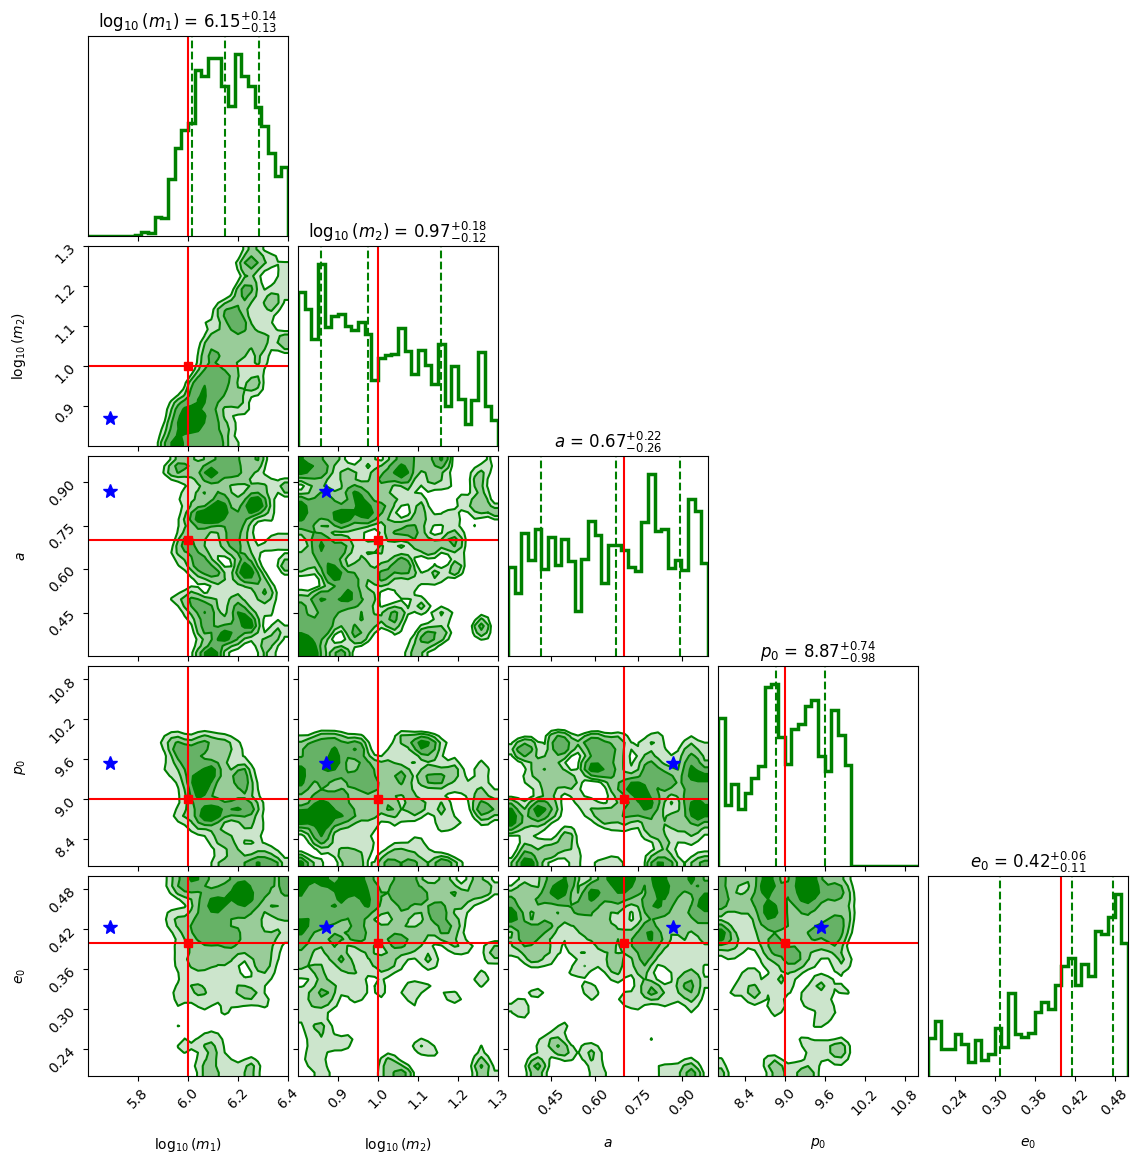

In [15]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [16]:
np.sort(logden_list)

array([[       -inf,        -inf,        -inf, ..., 15.95479809,
        16.3630634 , 16.39479839],
       [       -inf,        -inf,        -inf, ..., 15.25682033,
        15.30474021, 15.86435716]])

In [17]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([374, 517,   0, 288, 820, 797, 438, 238, 282, 604])

In [18]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[5.66676003, 0.81480678, 0.80306503, 9.57880491, 0.3368511 ],
       [5.66671916, 0.80360649, 0.80825708, 9.61802253, 0.34416826],
       [5.671604  , 0.8031475 , 0.79984635, 9.569065  , 0.3395315 ],
       [5.67715147, 0.80302305, 0.8001113 , 9.60609559, 0.33772456],
       [5.66554877, 0.80554066, 0.80249811, 9.65243352, 0.34046966],
       [5.66647796, 0.80493356, 0.8045154 , 9.61636277, 0.34317703],
       [5.66005537, 0.80792151, 0.79486664, 9.58229143, 0.33998611],
       [5.66142048, 0.79889233, 0.80933138, 9.54942201, 0.34167317],
       [5.67572976, 0.79634345, 0.81523543, 9.58448892, 0.34211705],
       [5.67025204, 0.80318187, 0.80624124, 9.58147082, 0.34378372]])

In [19]:
np.average(top10_pts.T[0])

5.668171904978324

In [20]:
np.average(top10_pts.T[1])

0.8041397203781605

In [21]:
np.average(top10_pts.T[2])

0.8043967958883279

In [22]:
np.average(top10_pts.T[3])

9.59384575020808

In [23]:
np.average(top10_pts.T[4])

0.34094821588586266

In [24]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [25]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [26]:
import matplotlib.pyplot as plt

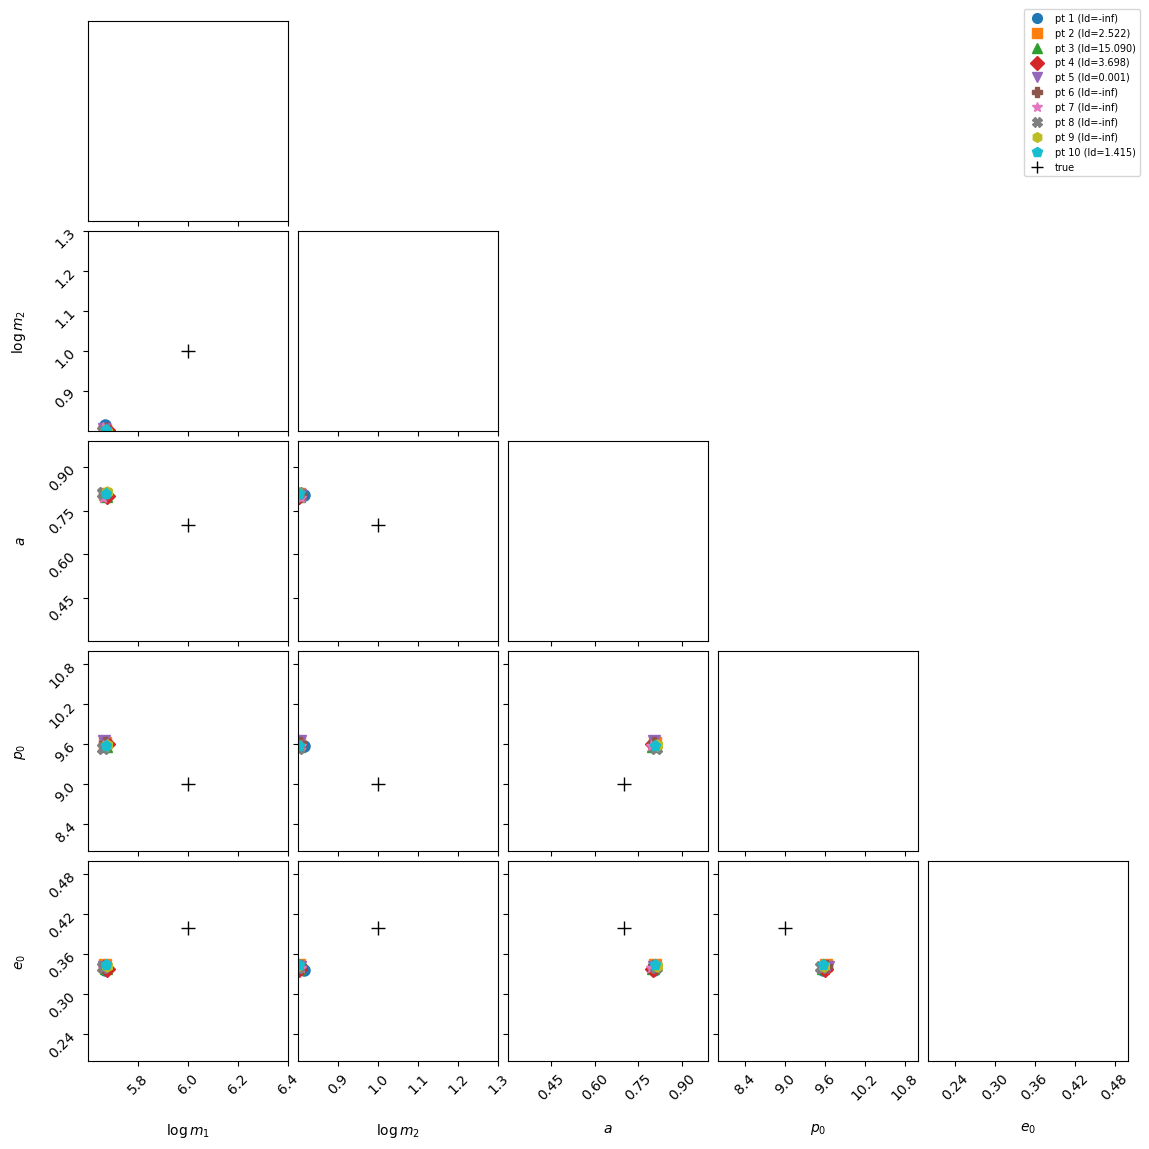

In [27]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

# connection plot

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.68947383, 0.86959776, 0.86889644, 9.54703157, 0.42287033]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [30]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [32]:
logden_theory_proc1

array([16.39479839,  1.86811854,  3.56150021,  3.08698954,  4.36882304,
        3.6042318 ,  3.36856985,  4.28382821,  3.61303928,  4.38227463,
        4.09652846,  4.09583651,  4.46034564,  3.82430575,  4.56544511,
        4.33399393,  4.95844104,  4.37098118,  4.93005302,  4.43343418,
        4.80925374,  4.6298963 ,  4.80382068,  5.08603193,  4.74913653,
        5.28180111,  5.03800899,  4.94161479,  4.9704699 ,  6.01647506,
        5.74324941,  6.32131748,  5.91653375,  5.50765446,  6.38108739,
        6.61997666,  6.35899535,  6.12438551,  6.42669812,  7.08947935,
        6.70718536,  6.64149297,  6.68536947,  6.91107357,  7.30644173,
        7.13818374,  7.42350593,  8.33189119,  8.29754155, 24.71883154])

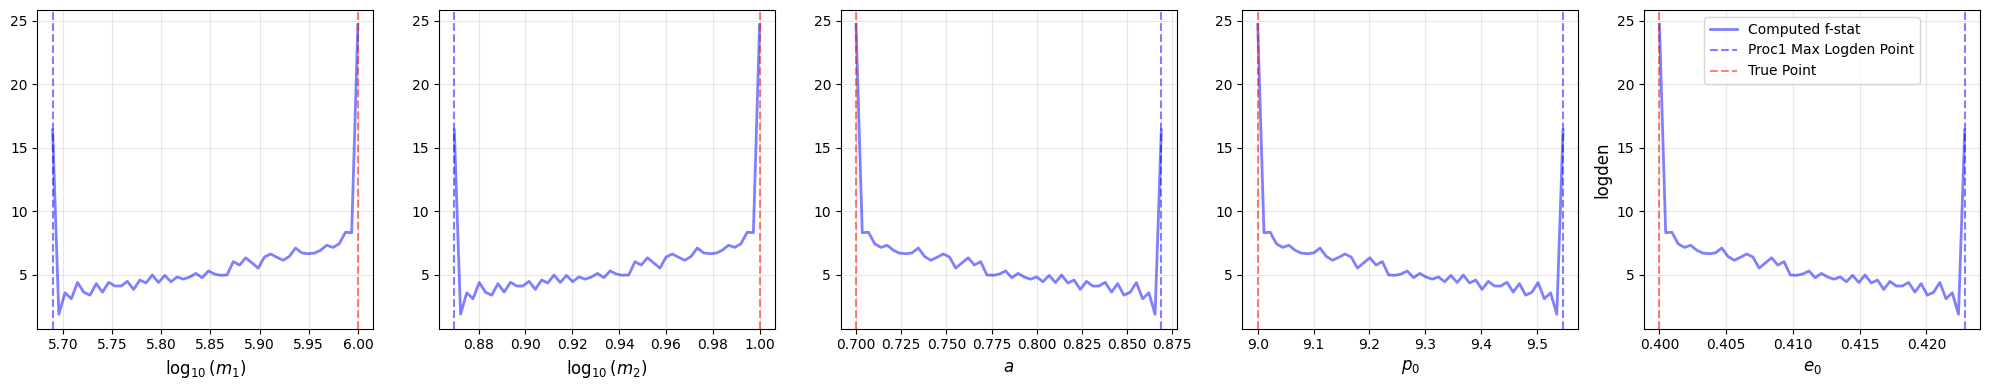

In [33]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [ ]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [36]:
logden_tm = log_density(line_points_logm1.T)


  [warn] sample 0 failed: 
  [warn] sample 1 failed: 
  [warn] sample 2 failed: 
  [warn] sample 3 failed: 
  [warn] sample 4 failed: 
  [warn] sample 5 failed: 
  [warn] sample 6 failed: 
  [warn] sample 7 failed: 
  [warn] sample 8 failed: 
  [warn] sample 9 failed: 
  [warn] sample 10 failed: 
  [warn] sample 11 failed: 


  [warn] sample 12 failed: 
  [warn] sample 13 failed: 
  [warn] sample 14 failed: 
  [warn] sample 15 failed: 
  [warn] sample 16 failed: 
  [warn] sample 17 failed: 
  [warn] sample 18 failed: 
  [warn] sample 19 failed: 
  [warn] sample 20 failed: 
  [warn] sample 21 failed: 


In [ ]:
logden_tm

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,  0.10641546, 16.39479839,  0.8903092 ,
        1.3172825 ,  3.45228443,  1.94116394,  3.73402642,  4.63775673,
        3.23244824,  3.42745674,  3.59400644,  3.53090081,  4.11413404,
        3.82441436,  4.3500266 ,  4.5383523 ,  4.65423963,  3.83856178,
        4.20524725,  4.14453258,  3.95876271,  4.63580987,  4.67357596,
        4.52905783,  4.50601275,  4.68742416,  4.92747372,  5.33919248,
        4.70751045,  4.45886731,  4.60721994,  5.21672535,  4.76133592,
        4.3635233 ,  4.55160938,  5.67822381,  4.77613427,  4.85637746,
        4.85631738,  4.74723529,  5.64062117,  4.87850639,  5.21398306,
        5.72126018,  5.3172846 ,  6.33266721,  5.37624888,  5.28

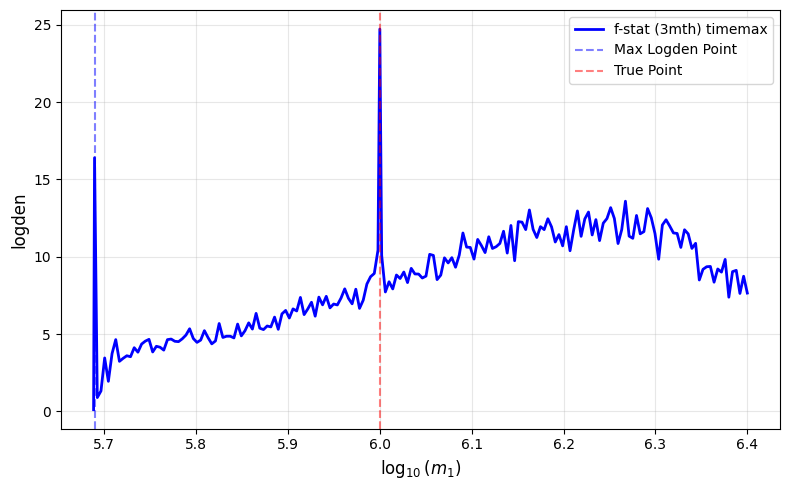

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [39]:
def log_density_sn(params):
    """Semi-coherent statistic S_N version of log_density.

    Uses gwf.SNR_semicoherent (the plain semi-coherent statistic S_N)
    instead of the semi-coherent f-statistic Sf, so no per-mode
    templates are needed.
    """
    params = np.asarray(params)
    n = params.shape[0]
    out = np.full(n, -np.inf)
    for i in range(n):
        try:
            logm1, logm2, a_i, p0_i, e0_i = params[i]
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            h_temp = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp,
                                                N_seg=N_SEGS))
        except Exception as exc:
            print(f"  [warn] sample {i} failed: {exc}")
    return out


In [40]:
logden_sn = log_density_sn(line_points_logm1.T)


  [warn] sample 0 failed: 
  [warn] sample 1 failed: 
  [warn] sample 2 failed: 
  [warn] sample 3 failed: 
  [warn] sample 4 failed: 
  [warn] sample 5 failed: 
  [warn] sample 6 failed: 
  [warn] sample 7 failed: 
  [warn] sample 8 failed: 
  [warn] sample 9 failed: 
  [warn] sample 10 failed: 
  [warn] sample 11 failed: 
  [warn] sample 12 failed: 
  [warn] sample 13 failed: 
  [warn] sample 14 failed: 
  [warn] sample 15 failed: 
  [warn] sample 16 failed: 
  [warn] sample 17 failed: 
  [warn] sample 18 failed: 
  [warn] sample 19 failed: 
  [warn] sample 20 failed: 
  [warn] sample 21 failed: 


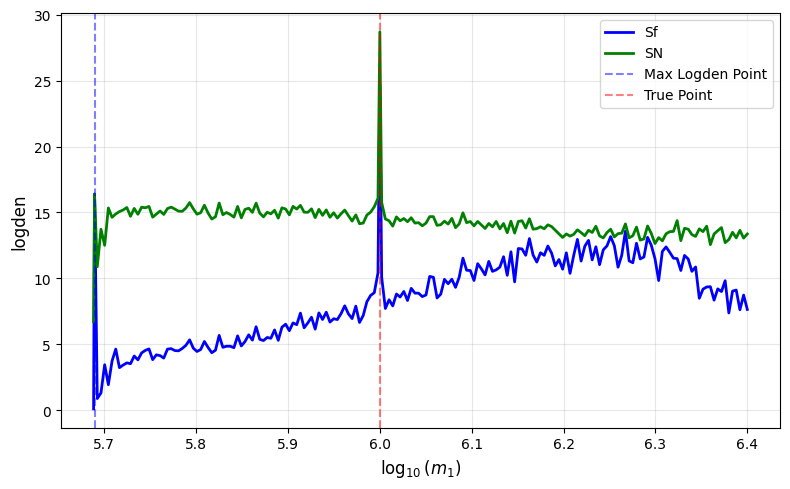

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='Sf')
ax.plot(line_points_logm1[0], logden_sn, '-', color='green', linewidth=2, label='SN')

# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()